In [23]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pickle

from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

In [2]:
NUM_CLASSES = 36
WINDOW_SIZE = 65
IGNORE_INDEX = -100

device = torch.device("cuda" if torch.cuda.is_available() else "mps")
device

device(type='mps')

In [3]:
criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

In [8]:
DATA_DIR = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"

In [11]:
train_path = PROCESSED_DIR / "train_windows_65.pkl"
val_path = PROCESSED_DIR / "val_windows_65.pkl"
test_path = PROCESSED_DIR / "test_windows_65.pkl"

with open(train_path, "rb") as f:
    train_windows = pickle.load(f)

with open(val_path, "rb") as f:
    val_windows = pickle.load(f)

with open(test_path, "rb") as f:
    test_windows = pickle.load(f)

print(len(train_windows), len(val_windows), len(test_windows))

929004 113997 118229


In [12]:
FEATURE_COLUMNS = [
    "resname",
    "polarity_group",
    "hydropathy_group",
    "volume_group",
    "chemical_group",
    "physicochemical_group",
    "charge_group",
    "hydrogen_donor_acceptor_group",
]

WINDOW_SIZE = 65
IGNORE_INDEX = -100

In [14]:
PAD_TOKEN = "PAD"
UNK_TOKEN = "UNK"

cat_to_idx = {}

for col in FEATURE_COLUMNS:
    values = set()

    for sample in train_windows:
        for residue_features in sample["features"]:
            values.add(residue_features[col])

    values = sorted(values)

    vocab = [PAD_TOKEN, UNK_TOKEN]
    for value in values:
        if value not in vocab:
            vocab.append(value)

    cat_to_idx[col] = {value: idx for idx, value in enumerate(vocab)}

In [15]:
cat_vocab_sizes = [len(cat_to_idx[col]) for col in FEATURE_COLUMNS]

cat_embedding_dims = [
    min(32, max(4, vocab_size // 2))
    for vocab_size in cat_vocab_sizes
]

print("Vocab sizes:", cat_vocab_sizes)
print("Embedding dims:", cat_embedding_dims)

Vocab sizes: [22, 4, 5, 6, 13, 11, 6, 6]
Embedding dims: [11, 4, 4, 4, 6, 5, 4, 4]


In [24]:
class Chi1WindowDataset(Dataset):
    def __init__(self, samples, feature_columns, cat_to_idx):
        self.samples = samples
        self.feature_columns = feature_columns
        self.cat_to_idx = cat_to_idx

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        x_cat = []

        for residue_features in sample["features"]:
            row = []

            for col in self.feature_columns:
                value = residue_features[col]
                value_idx = self.cat_to_idx[col].get(value, self.cat_to_idx[col][UNK_TOKEN])
                row.append(value_idx)

            x_cat.append(row)

        x_cat = torch.tensor(x_cat, dtype=torch.long)
        y = torch.tensor(sample["targets"], dtype=torch.long)
        target_mask = torch.tensor(sample["target_mask"], dtype=torch.bool)
        padding_mask = torch.tensor(sample["padding_mask"], dtype=torch.bool)

        return {
            "x_cat": x_cat,
            "y": y,
            "target_mask": target_mask,
            "padding_mask": padding_mask,
        }

In [25]:
train_dataset = Chi1WindowDataset(
    samples=train_windows,
    feature_columns=FEATURE_COLUMNS,
    cat_to_idx=cat_to_idx,
)

val_dataset = Chi1WindowDataset(
    samples=val_windows,
    feature_columns=FEATURE_COLUMNS,
    cat_to_idx=cat_to_idx,
)

test_dataset = Chi1WindowDataset(
    samples=test_windows,
    feature_columns=FEATURE_COLUMNS,
    cat_to_idx=cat_to_idx,
)

In [26]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

In [27]:
batch = next(iter(train_loader))

print(batch["x_cat"].shape)
print(batch["y"].shape)
print(batch["target_mask"].shape)
print(batch["padding_mask"].shape)

torch.Size([128, 65, 8])
torch.Size([128, 65])
torch.Size([128, 65])
torch.Size([128, 65])


In [16]:
def circular_bin_distance(pred_bins, true_bins, num_bins=36):
    diff = torch.abs(pred_bins - true_bins)
    return torch.minimum(diff, num_bins - diff)

In [17]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0
    total_valid = 0

    total_exact_correct = 0
    total_pm1_correct = 0
    total_pm3_correct = 0
    total_distance = 0.0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for batch in progress_bar:
        x_cat = batch["x_cat"].to(device)
        y = batch["y"].to(device)
        target_mask = batch["target_mask"].to(device)
        padding_mask = batch["padding_mask"].to(device)

        optimizer.zero_grad()

        logits = model(x_cat, padding_mask=padding_mask)

        loss = criterion(
            logits.reshape(-1, NUM_CLASSES),
            y.reshape(-1),
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        with torch.no_grad():
            pred_bins = torch.argmax(logits, dim=-1)
            valid_mask = target_mask & (y != IGNORE_INDEX)

            if valid_mask.sum() > 0:
                pred_valid = pred_bins[valid_mask]
                y_valid = y[valid_mask]

                distances = circular_bin_distance(
                    pred_valid,
                    y_valid,
                    num_bins=NUM_CLASSES,
                )

                num_valid = int(valid_mask.sum().item())

                total_valid += num_valid
                total_loss += loss.item() * num_valid

                total_exact_correct += int((distances == 0).sum().item())
                total_pm1_correct += int((distances <= 1).sum().item())
                total_pm3_correct += int((distances <= 3).sum().item())
                total_distance += float(distances.float().sum().item())

                progress_bar.set_postfix({
                    "loss": total_loss / total_valid,
                    "acc@±3": total_pm3_correct / total_valid,
                })

    metrics = {
        "loss": total_loss / total_valid,
        "acc_exact": total_exact_correct / total_valid,
        "acc_pm1": total_pm1_correct / total_valid,
        "acc_pm3": total_pm3_correct / total_valid,
        "mean_circular_distance": total_distance / total_valid,
    }

    return metrics

In [18]:
def evaluate(model, loader, criterion, device, desc="Validation"):
    model.eval()

    total_loss = 0.0
    total_valid = 0

    total_exact_correct = 0
    total_pm1_correct = 0
    total_pm3_correct = 0
    total_distance = 0.0

    progress_bar = tqdm(loader, desc=desc, leave=False)

    with torch.no_grad():
        for batch in progress_bar:
            x_cat = batch["x_cat"].to(device)
            y = batch["y"].to(device)
            target_mask = batch["target_mask"].to(device)
            padding_mask = batch["padding_mask"].to(device)

            logits = model(x_cat, padding_mask=padding_mask)

            loss = criterion(
                logits.reshape(-1, NUM_CLASSES),
                y.reshape(-1),
            )

            pred_bins = torch.argmax(logits, dim=-1)
            valid_mask = target_mask & (y != IGNORE_INDEX)

            if valid_mask.sum() > 0:
                pred_valid = pred_bins[valid_mask]
                y_valid = y[valid_mask]

                distances = circular_bin_distance(
                    pred_valid,
                    y_valid,
                    num_bins=NUM_CLASSES,
                )

                num_valid = int(valid_mask.sum().item())

                total_valid += num_valid
                total_loss += loss.item() * num_valid

                total_exact_correct += int((distances == 0).sum().item())
                total_pm1_correct += int((distances <= 1).sum().item())
                total_pm3_correct += int((distances <= 3).sum().item())
                total_distance += float(distances.float().sum().item())

                progress_bar.set_postfix({
                    "loss": total_loss / total_valid,
                    "acc@±3": total_pm3_correct / total_valid,
                })

    metrics = {
        "loss": total_loss / total_valid,
        "acc_exact": total_exact_correct / total_valid,
        "acc_pm1": total_pm1_correct / total_valid,
        "acc_pm3": total_pm3_correct / total_valid,
        "mean_circular_distance": total_distance / total_valid,
    }

    return metrics

In [19]:
class NestedChi1Transformer(nn.Module):
    def __init__(
        self,
        cat_vocab_sizes,
        cat_embedding_dims,
        d_model=128,
        nhead=8,
        inner_num_layers=3,
        outer_num_layers=2,
        inner_dim_feedforward=256,
        outer_dim_feedforward=256,
        dropout=0.1,
        num_classes=36,
        window_size=65,
    ):
        super().__init__()

        self.window_size = window_size
        self.d_model = d_model

        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(
                num_embeddings=vocab_size,
                embedding_dim=emb_dim,
                padding_idx=0,
            )
            for vocab_size, emb_dim in zip(cat_vocab_sizes, cat_embedding_dims)
        ])

        total_cat_dim = sum(cat_embedding_dims)

        self.input_projection = nn.Sequential(
            nn.Linear(total_cat_dim, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
        )

        self.position_embedding = nn.Embedding(window_size, d_model)

        inner_encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=inner_dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.inner_transformer = nn.TransformerEncoder(
            encoder_layer=inner_encoder_layer,
            num_layers=inner_num_layers,
        )

        self.inner_norm = nn.LayerNorm(d_model)

        outer_encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=outer_dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.outer_transformer = nn.TransformerEncoder(
            encoder_layer=outer_encoder_layer,
            num_layers=outer_num_layers,
        )

        self.outer_norm = nn.LayerNorm(d_model)

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, x_cat, padding_mask=None):
        batch_size, seq_len, num_features = x_cat.shape

        embedded_features = []

        for feature_idx, embedding_layer in enumerate(self.cat_embeddings):
            feature_values = x_cat[:, :, feature_idx]
            feature_emb = embedding_layer(feature_values)
            embedded_features.append(feature_emb)

        x = torch.cat(embedded_features, dim=-1)
        x = self.input_projection(x)

        positions = torch.arange(seq_len, device=x.device)
        positions = positions.unsqueeze(0).expand(batch_size, seq_len)

        x = x + self.position_embedding(positions)

        inner_hidden = self.inner_transformer(
            x,
            src_key_padding_mask=padding_mask,
        )

        inner_hidden = self.inner_norm(inner_hidden)

        outer_input = x + inner_hidden

        outer_hidden = self.outer_transformer(
            outer_input,
            src_key_padding_mask=padding_mask,
        )

        outer_hidden = self.outer_norm(outer_hidden)

        final_hidden = inner_hidden + outer_hidden

        logits = self.classifier(final_hidden)

        return logits

In [20]:
nested_model = NestedChi1Transformer(
    cat_vocab_sizes=cat_vocab_sizes,
    cat_embedding_dims=cat_embedding_dims,
    d_model=128,
    nhead=8,
    inner_num_layers=3,
    outer_num_layers=2,
    inner_dim_feedforward=256,
    outer_dim_feedforward=256,
    dropout=0.1,
    num_classes=NUM_CLASSES,
    window_size=WINDOW_SIZE,
).to(device)

nested_model

/opt/anaconda3/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


NestedChi1Transformer(
  (cat_embeddings): ModuleList(
    (0): Embedding(22, 11, padding_idx=0)
    (1): Embedding(4, 4, padding_idx=0)
    (2): Embedding(5, 4, padding_idx=0)
    (3): Embedding(6, 4, padding_idx=0)
    (4): Embedding(13, 6, padding_idx=0)
    (5): Embedding(11, 5, padding_idx=0)
    (6-7): 2 x Embedding(6, 4, padding_idx=0)
  )
  (input_projection): Sequential(
    (0): Linear(in_features=42, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): Dropout(p=0.1, inplace=False)
  )
  (position_embedding): Embedding(65, 128)
  (inner_transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linea

In [28]:
batch = next(iter(train_loader))

x_cat = batch["x_cat"].to(device)
padding_mask = batch["padding_mask"].to(device)

with torch.no_grad():
    logits = nested_model(x_cat, padding_mask=padding_mask)

print(logits.shape)

torch.Size([128, 65, 36])


In [29]:
nested_optimizer = torch.optim.AdamW(
    nested_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4,
)

In [30]:
NUM_EPOCHS = 10

nested_history = []

best_nested_val_acc_pm3 = -1.0
best_nested_model_path = PROCESSED_DIR / "best_nested_chi1_transformer.pt"

In [31]:
for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc="Epochs"):
    train_metrics = train_one_epoch(
        model=nested_model,
        loader=train_loader,
        optimizer=nested_optimizer,
        criterion=criterion,
        device=device,
    )

    val_metrics = evaluate(
        model=nested_model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        desc="Validation",
    )

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_acc_exact": train_metrics["acc_exact"],
        "train_acc_pm1": train_metrics["acc_pm1"],
        "train_acc_pm3": train_metrics["acc_pm3"],
        "train_mean_circular_distance": train_metrics["mean_circular_distance"],
        "val_loss": val_metrics["loss"],
        "val_acc_exact": val_metrics["acc_exact"],
        "val_acc_pm1": val_metrics["acc_pm1"],
        "val_acc_pm3": val_metrics["acc_pm3"],
        "val_mean_circular_distance": val_metrics["mean_circular_distance"],
    }

    nested_history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_metrics['loss']:.4f} | "
        f"train acc@±3 {train_metrics['acc_pm3']:.4f} | "
        f"val loss {val_metrics['loss']:.4f} | "
        f"val acc@±3 {val_metrics['acc_pm3']:.4f} | "
        f"val exact {val_metrics['acc_exact']:.4f}"
    )

    if val_metrics["acc_pm3"] > best_nested_val_acc_pm3:
        best_nested_val_acc_pm3 = val_metrics["acc_pm3"]

        torch.save(
            {
                "model_state_dict": nested_model.state_dict(),
                "cat_to_idx": cat_to_idx,
                "feature_columns": FEATURE_COLUMNS,
                "cat_vocab_sizes": cat_vocab_sizes,
                "cat_embedding_dims": cat_embedding_dims,
                "model_config": {
                    "d_model": 128,
                    "nhead": 8,
                    "inner_num_layers": 3,
                    "outer_num_layers": 2,
                    "inner_dim_feedforward": 256,
                    "outer_dim_feedforward": 256,
                    "dropout": 0.1,
                    "num_classes": NUM_CLASSES,
                    "window_size": WINDOW_SIZE,
                },
                "best_val_acc_pm3": best_nested_val_acc_pm3,
                "epoch": epoch,
            },
            best_nested_model_path,
        )

        print(f"Saved best nested model to {best_nested_model_path}")

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Training:   0%|          | 0/7258 [00:00<?, ?it/s]

Validation:   0%|          | 0/891 [00:00<?, ?it/s]

Epoch 01 | train loss 2.5797 | train acc@±3 0.5398 | val loss 2.4744 | val acc@±3 0.5599 | val exact 0.2484
Saved best nested model to data/processed/best_nested_chi1_transformer.pt


Training:   0%|          | 0/7258 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/891 [00:00<?, ?it/s]

Epoch 09 | train loss 2.3493 | train acc@±3 0.6035 | val loss 2.3125 | val acc@±3 0.6160 | val exact 0.3032
Saved best nested model to data/processed/best_nested_chi1_transformer.pt


Training:   0%|          | 0/7258 [00:00<?, ?it/s]

Validation:   0%|          | 0/891 [00:00<?, ?it/s]

Epoch 10 | train loss 2.3364 | train acc@±3 0.6062 | val loss 2.3081 | val acc@±3 0.6176 | val exact 0.3039
Saved best nested model to data/processed/best_nested_chi1_transformer.pt


In [32]:
nested_history_df = pd.DataFrame(nested_history)
nested_history_df

,epoch,train_loss,train_acc_exact,train_acc_pm1,train_acc_pm3,train_mean_circular_distance,val_loss,val_acc_exact,val_acc_pm1,val_acc_pm3,val_mean_circular_distance
0,1,2.579694,0.221816,0.445254,0.539767,5.436920,2.474403,0.248423,0.467922,0.559938,5.205589
1,2,2.497315,0.244146,0.464166,0.557565,5.223232,2.425878,0.268954,0.486512,0.577996,4.989171
2,3,2.462500,0.256993,0.476408,0.569065,5.081690,2.387202,0.282730,0.499735,0.590316,4.836405
3,4,2.432505,0.267755,0.487503,0.579512,4.956606,2.364890,0.288332,0.506251,0.596697,4.760883
4,5,2.412245,0.273509,0.494184,0.586161,4.880230,2.347345,0.293310,0.513034,0.603347,4.687694
5,6,2.394036,0.278242,0.500407,0.592324,4.810314,2.330726,0.297318,0.518578,0.609034,4.623891
6,7,2.377195,0.282070,0.505393,0.597115,4.756881,2.320150,0.299788,0.521724,0.611989,4.593464
7,8,2.362698,0.284886,0.508875,0.600477,4.717723,2.315848,0.301607,0.523749,0.614277,4.563524
8,9,2.349250,0.287271,0.511866,0.603498,4.683001,2.312544,0.303222,0.525462,0.616032,4.540536
9,10,2.336431,0.289390,0.514593,0.606248,4.651004,2.308113,0.303929,0.526854,0.617599,4.521038


In [33]:
nested_history_path = PROCESSED_DIR / "training_history_nested_chi1_transformer.csv"
nested_history_df.to_csv(nested_history_path, index=False)

print("Saved history:", nested_history_path)

Saved history: data/processed/training_history_nested_chi1_transformer.csv


In [34]:
base_history_path = PROCESSED_DIR / "training_history_chi1_transformer.csv"
history_df = pd.read_csv(base_history_path)

In [35]:
print("Base Transformer best val acc@±3:", history_df["val_acc_pm3"].max())
print("Nested Transformer best val acc@±3:", nested_history_df["val_acc_pm3"].max())

Base Transformer best val acc@±3: 0.6177361947807982
Nested Transformer best val acc@±3: 0.6175988399422934


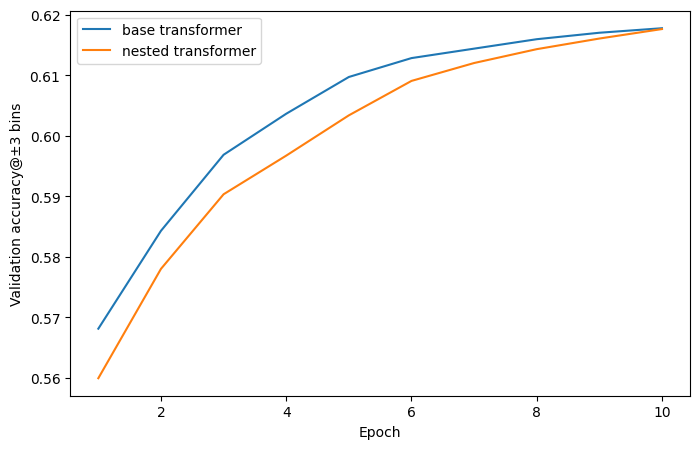

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_acc_pm3"], label="base transformer")
plt.plot(nested_history_df["epoch"], nested_history_df["val_acc_pm3"], label="nested transformer")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy@±3 bins")
plt.legend()
plt.show()